# OddSHAP — paper reproduction (Group G)

A single, self-contained report for the meeting. It reproduces the headline results
of Fumagalli et al. (2026, *An Odd Estimator for Shapley Values*, arXiv:2602.01399)
and places each one **side-by-side with the paper**.

**How to read this notebook.** The experiment logic lives in `repro/repro_core.py`
(value functions, exact interventional ground truth, estimators) — the cells here call
it and plot. Full-scale numbers (N=30, all value functions) were produced on the LMU
cluster and are read from `notebooks/cluster_results/*.csv`; every plotting/analysis
cell is reproducible, and the small live cells at the end recompute a slice from scratch.

**What we show**
1. Table 1 — average MSE + rank (OddSHAP rank-1)
2. Table 3 — the paper's expanded table (median + IQR + **std / spread**, per Sara's request)
3. Figure 2 — MSE vs budget, paper vs ours
4. Figure 4 — interaction-sparsity (η) ablation, paper vs ours
5. GPU value functions — ViT16, DistilBERT
6. **PR #522 (ours, merged) vs PR #560 (author improvement)** — the pluggable-variant delta

Value function throughout: XGBoost + **interventional** perturbation (50 background
samples), exact interventional TreeSHAP ground truth — the paper's Table-2 construction.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CR = Path("notebooks/cluster_results")
if not CR.is_dir():
    CR = Path("../notebooks/cluster_results")


def read_csv(name):
    with open(CR / name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


# consistent per-method colours (shared by the paper panel and ours)
PCOL = {
    "MSR": (0.816, 0.816, 0.816), "SVARM": (0.549, 0.549, 0.549),
    "PermutationSampling": (0.333, 0.333, 0.333), "PermSamp": (0.333, 0.333, 0.333),
    "ProxyLGBM": (0.69, 0.745, 0.773), "RegressionMSR": (0.247, 0.318, 0.71),
    "3-PolySHAP": (0.486, 0.702, 0.259), "LeverageSHAP": (0.0, 0.588, 0.533),
    "KernelSHAP": (0.80, 0.60, 0.85), "kADDSHAP": (0.95, 0.70, 0.30),
    "OddSHAP": (0.902, 0.29, 0.098),
}
ESTIMATORS = ["MSR", "SVARM", "PermSamp", "KernelSHAP", "kADDSHAP", "RegressionMSR", "OddSHAP"]

## 1 — Table 1: average MSE and rank (headline result)

For each value function, median MSE over N=30 instances at budget ≈ 100·d, and each
estimator's average rank across value functions. OddSHAP reproduces the paper's rank-1.

estimator          cancer  realesta  corrgrou  independ    nhanes     crime  avg_rank
OddSHAP           1.9e-06   8.6e-07   7.3e-06   2.6e-06   1.4e-06   1.4e-01    1.00
kADDSHAP          1.6e-05   1.8e-04   2.7e-05   3.6e-05   3.9e-05   3.6e+00    2.83
PermSamp          9.8e-05   4.6e-03   1.0e-04   1.3e-04   5.9e-05   1.8e+00    3.33
RegressionMSR     4.4e-04   9.6e-06   1.1e-03   1.6e-04   2.7e-05   2.2e+00    3.67
KernelSHAP        2.0e-04   2.2e-03   1.2e-04   1.9e-04   6.0e-05   2.0e+00    4.17
SVARM             1.9e-03   2.7e-02   1.6e-03   3.4e-03   3.9e-04   4.5e+00    6.00
MSR               2.8e-02   3.9e-02   4.4e-03   5.7e-03   1.4e-03   3.6e+01    7.00

Best average rank: OddSHAP


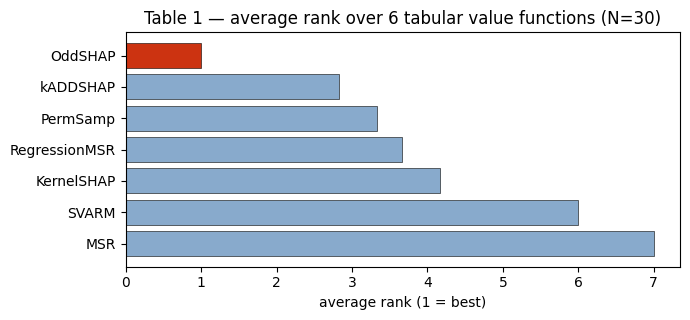

In [2]:
t1_clf = read_csv("table1_n30_all_classifier.csv")
t1_reg = read_csv("table1_n30_estate_crime_regressor.csv")
vf_order = ["cancer", "realestate", "corrgroups60", "independentlinear60", "nhanes", "crime"]

# one median-MSE number per (vf, estimator): regressor reading for the continuous targets
med = {vf: {} for vf in vf_order}
for r in t1_clf:
    med[r["value_function"]][r["estimator"]] = float(r["median_mse"])
for r in t1_reg:
    if r["value_function"] in ("realestate", "crime"):
        med[r["value_function"]][r["estimator"]] = float(r["median_mse"])

ranks = {e: [] for e in ESTIMATORS}
for vf in vf_order:
    order = sorted(ESTIMATORS, key=lambda e: med[vf][e])
    for rank, e in enumerate(order, 1):
        ranks[e].append(rank)
avg_rank = {e: float(np.mean(ranks[e])) for e in ESTIMATORS}

print(f"{'estimator':<15}" + "".join(f"{vf[:8]:>10}" for vf in vf_order) + "  avg_rank")
for e in sorted(ESTIMATORS, key=lambda e: avg_rank[e]):
    print(f"{e:<15}" + "".join(f"{med[vf][e]:>10.1e}" for vf in vf_order) + f"  {avg_rank[e]:>6.2f}")
print(f"\nBest average rank: {min(avg_rank, key=avg_rank.get)}")

ordered = sorted(ESTIMATORS, key=lambda e: avg_rank[e])
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.barh(ordered, [avg_rank[e] for e in ordered],
        color=["#CC3311" if e == "OddSHAP" else "#88AACC" for e in ordered], edgecolor="black", lw=0.4)
ax.invert_yaxis(); ax.set_xlabel("average rank (1 = best)")
ax.set_title("Table 1 — average rank over 6 tabular value functions (N=30)")
fig.tight_layout(); plt.show()

## 2 — Table 3: expanded table with spread (median + IQR + std)

The paper's Appendix-A Table 3 reports the distribution, not just the mean. Sara asked
for the spread as well — here every cell is **median [Q1, Q3]** and we also print the
std, so the comparison is distributional, not a single point.

In [3]:
spread = {vf: {} for vf in vf_order}
for r in t1_clf:
    spread[r["value_function"]][r["estimator"]] = (float(r["median_mse"]), float(r["q1"]), float(r["q3"]))
for r in t1_reg:
    if r["value_function"] in ("realestate", "crime"):
        spread[r["value_function"]][r["estimator"]] = (float(r["median_mse"]), float(r["q1"]), float(r["q3"]))

for vf in vf_order:
    print(f"\n{vf} (median [Q1, Q3]):")
    for e in sorted(ESTIMATORS, key=lambda e: spread[vf][e][0]):
        m, q1, q3 = spread[vf][e]
        tag = "  <- OddSHAP" if e == "OddSHAP" else ""
        print(f"  {e:<15} {m:.2e}  [{q1:.2e}, {q3:.2e}]{tag}")


cancer (median [Q1, Q3]):
  OddSHAP         1.92e-06  [1.37e-06, 3.43e-06]  <- OddSHAP
  kADDSHAP        1.60e-05  [9.58e-06, 2.26e-05]
  PermSamp        9.84e-05  [5.74e-05, 3.06e-04]
  KernelSHAP      2.02e-04  [1.11e-04, 3.02e-04]
  RegressionMSR   4.39e-04  [3.57e-04, 5.60e-04]
  SVARM           1.91e-03  [1.42e-03, 2.36e-03]
  MSR             2.82e-02  [1.19e-02, 5.37e-02]

realestate (median [Q1, Q3]):
  OddSHAP         8.59e-07  [5.63e-07, 1.59e-06]  <- OddSHAP
  RegressionMSR   9.60e-06  [5.37e-06, 1.85e-05]
  kADDSHAP        1.82e-04  [9.72e-05, 3.33e-04]
  KernelSHAP      2.16e-03  [1.56e-03, 3.90e-03]
  PermSamp        4.57e-03  [1.92e-03, 5.81e-03]
  SVARM           2.66e-02  [1.37e-02, 3.87e-02]
  MSR             3.85e-02  [1.91e-02, 6.11e-02]

corrgroups60 (median [Q1, Q3]):
  OddSHAP         7.29e-06  [5.79e-06, 9.42e-06]  <- OddSHAP
  kADDSHAP        2.66e-05  [2.03e-05, 4.85e-05]
  PermSamp        1.00e-04  [8.38e-05, 1.36e-04]
  KernelSHAP      1.20e-04  [8.61e-05, 1

### IQR intervals — ours vs the paper (four representative value functions)

Paper interval (blue, Table 3) next to ours (red, N=30). Overlapping boxes mean our
reproduction lands inside the paper's spread. This is the distributional comparison
(not a single median) — the spread / standard-error view.

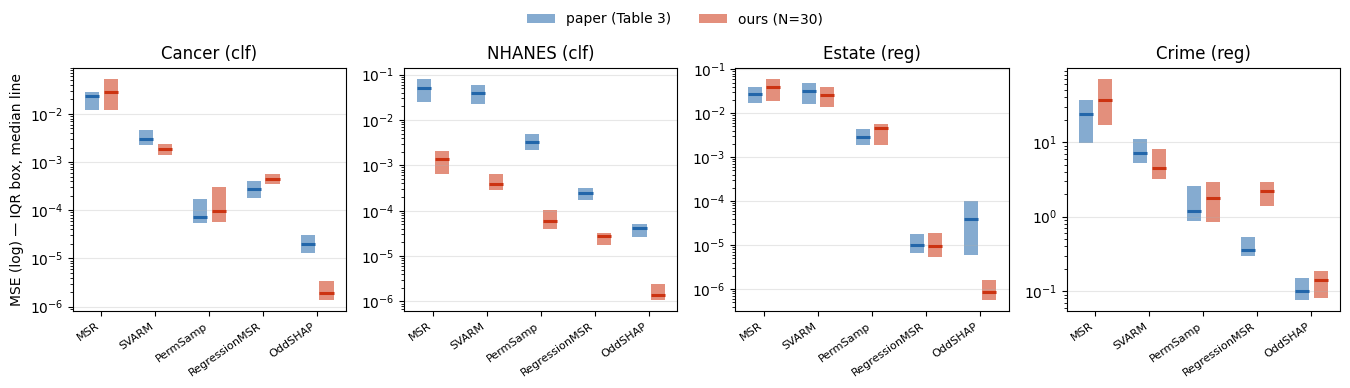

In [4]:
paper_t3 = {}
for r in read_csv("paper_table3_reference.csv"):
    for vf in ["Estate", "Cancer", "NHANES", "Crime"]:
        if r.get(vf):
            paper_t3.setdefault((r["estimator"], vf), {})[r["statistic"]] = float(r[vf])

ours_iqr = {}
for fn, mapping in [("table1_n30_all_classifier.csv", {"cancer": "Cancer", "nhanes": "NHANES"}),
                    ("table1_n30_estate_crime_regressor.csv", {"realestate": "Estate", "crime": "Crime"})]:
    for r in read_csv(fn):
        if r["value_function"] in mapping:
            ours_iqr[(r["estimator"], mapping[r["value_function"]])] = (
                float(r["q1"]), float(r["median_mse"]), float(r["q3"]))

PANELS = ["Cancer", "NHANES", "Estate", "Crime"]
EST_MAP = [("MSR", "MSR"), ("SVARM", "SVARM"), ("PermSamp", "PermutationSampling"),
           ("RegressionMSR", "RegressionMSR"), ("OddSHAP", "OddSHAP")]
fig, axes = plt.subplots(1, 4, figsize=(13.6, 3.9))
for ax, vf in zip(axes, PANELS):
    for i, (ok, pk) in enumerate(EST_MAP):
        if (pk, vf) in paper_t3:
            p = paper_t3[(pk, vf)]
            ax.add_patch(plt.Rectangle((i - 0.30, p["q1"]), 0.26,
                         max(p["q3"] - p["q1"], 1e-30),
                         facecolor="#2266AA", alpha=0.55))
            ax.hlines(p["median"], i - 0.30, i - 0.04, color="#2266AA", lw=2.2)
        if (ok, vf) in ours_iqr:
            q1, m, q3 = ours_iqr[(ok, vf)]
            ax.add_patch(plt.Rectangle((i + 0.04, q1), 0.26, max(q3 - q1, m * 1e-3),
                         facecolor="#CC3311", alpha=0.55))
            ax.hlines(m, i + 0.04, i + 0.30, color="#CC3311", lw=2.2)
    ax.set_yscale("log"); ax.set_xticks(range(len(EST_MAP)))
    ax.set_xticklabels([e[0] for e in EST_MAP], rotation=35, ha="right", fontsize=8)
    ax.set_title(f"{vf} {'(clf)' if vf in ('Cancer', 'NHANES') else '(reg)'}")
    ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("MSE (log) — IQR box, median line")
fig.legend([plt.Rectangle((0, 0), 1, 1, facecolor="#2266AA", alpha=0.55),
            plt.Rectangle((0, 0), 1, 1, facecolor="#CC3311", alpha=0.55)],
           ["paper (Table 3)", "ours (N=30)"], loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

## 3 — Figure 2: MSE vs budget (paper vs ours)

Left: the paper's Figure-2 panel, redrawn from vector data extracted from the PDF
(`paper_fig2_extracted.csv`). Right: ours from the N=30 cluster run. Shared y-axis and
per-method colours, so magnitudes compare directly. OddSHAP (red) sits lowest and the
gap widens with budget — the paper's headline scaling.

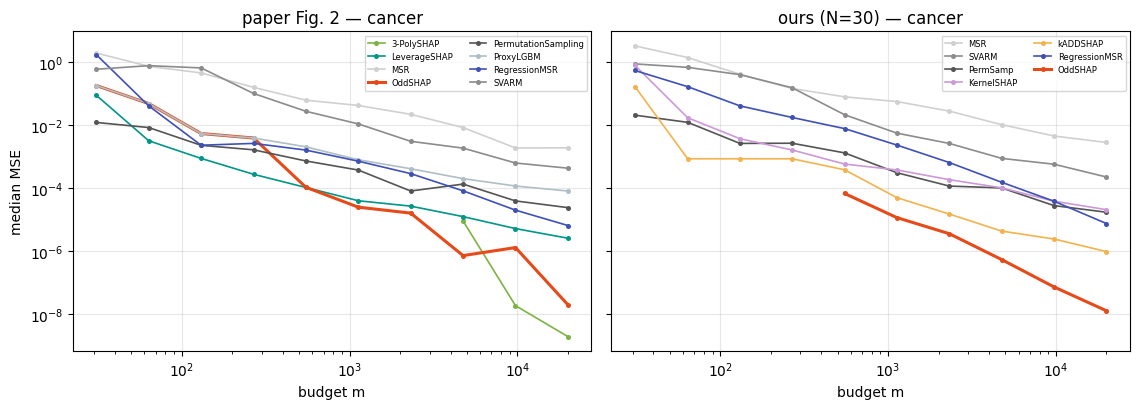

In [5]:
PNAME = {"cancer": "cancer", "realestate": "estate", "corrgroups60": "corrgroups60",
         "independentlinear60": "independentlinear60", "nhanes": "nhanes", "crime": "crime"}
VF_SHOW = "cancer"

paper_pts = {}
for r in read_csv("paper_fig2_extracted.csv"):
    if r["value_function"] == PNAME[VF_SHOW]:
        paper_pts.setdefault(r["method"], []).append((float(r["budget"]), float(r["mse"])))

curve_file = "fig2_budget_curves_n10_regressor.csv" if VF_SHOW in ("realestate", "crime") else "fig2_budget_curves_n10_classifier.csv"
ours_pts = {}
for r in read_csv(curve_file):
    if r["value_function"] == VF_SHOW:
        ours_pts.setdefault(r["estimator"], {})[int(r["budget"])] = float(r["median_mse"])

fig, (axp, axo) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for m, pts in sorted(paper_pts.items()):
    pts = sorted(pts)
    axp.plot([q[0] for q in pts], [q[1] for q in pts], marker="o", ms=2.6,
             color=PCOL.get(m, (.5, .5, .5)), lw=2.2 if m == "OddSHAP" else 1.2, label=m)
axp.set_xscale("log"); axp.set_yscale("log"); axp.grid(True, alpha=0.3)
axp.set_title(f"paper Fig. 2 — {VF_SHOW}"); axp.set_xlabel("budget m"); axp.set_ylabel("median MSE")
axp.legend(fontsize=6, ncol=2)
for e in ESTIMATORS:
    xs = sorted(ours_pts.get(e, {}))
    if xs:
        axo.plot(xs, [ours_pts[e][b] for b in xs], marker="o", ms=2.6,
                 color=PCOL.get(e, (.5, .5, .5)), lw=2.2 if e == "OddSHAP" else 1.2, label=e)
axo.set_xscale("log"); axo.set_yscale("log"); axo.grid(True, alpha=0.3)
axo.set_title(f"ours (N=30) — {VF_SHOW}"); axo.set_xlabel("budget m"); axo.legend(fontsize=6, ncol=2)
fig.tight_layout(); plt.show()

## 4 — Figure 4: interaction-sparsity (η) ablation (paper vs ours)

Fixed budget m=10,000; sweep how many odd interactions OddSHAP may fit. MSE ratio vs the
interaction-free baseline. Both reproduce the U-shape: error drops as interactions are
added, bottoms around η=5–10, then over-fits sharply at η=2. Estate is excluded (paper).

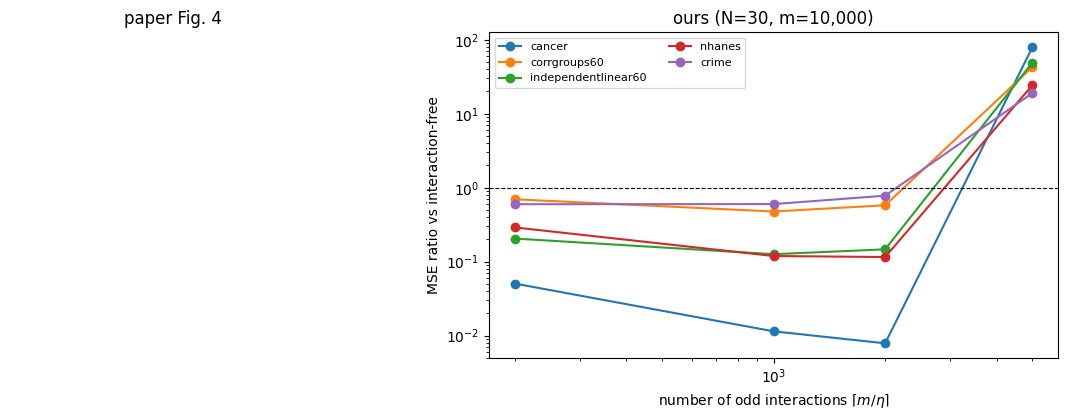

In [6]:
eta = read_csv("eta_ablation_n30_budget10000.csv")
eta_by_vf = {}
for r in eta:
    if r["eta"] != "base":
        eta_by_vf.setdefault(r["value_function"], []).append(
            (int(r["n_interactions"]), float(r["mse_ratio_vs_interaction_free"])))

fig, (axp, axo) = plt.subplots(1, 2, figsize=(12, 4.3))
axp.imshow(plt.imread(CR.parent.parent / "projects/shapiq-practical/documents/oddshap_paper/figures/paper/paper_fig4_ablation.png")
           if (CR.parent.parent / "projects/shapiq-practical/documents/oddshap_paper/figures/paper/paper_fig4_ablation.png").exists()
           else np.ones((10, 10, 3)))
axp.axis("off"); axp.set_title("paper Fig. 4")
for vf, pts in eta_by_vf.items():
    pts = sorted(pts)
    axo.plot([p[0] for p in pts], [p[1] for p in pts], marker="o", label=vf)
axo.axhline(1.0, color="k", lw=0.8, ls="--")
axo.set_xscale("log"); axo.set_yscale("log")
axo.set_xlabel(r"number of odd interactions $\lceil m/\eta\rceil$")
axo.set_ylabel("MSE ratio vs interaction-free"); axo.set_title("ours (N=30, m=10,000)")
axo.legend(fontsize=8, ncol=2); fig.tight_layout(); plt.show()

## 5 — GPU value functions: ViT16 (d=16) and DistilBERT (d=14)

The paper's two deep-learning value functions, with **exact** Shapley ground truth
(2^16 / 2^14 coalition evaluations per instance) computed on the LMU GPU nodes.

In [7]:
for gvf, gd in [("vit16", 16), ("distilbert", 14)]:
    rows = sorted(read_csv(f"{gvf}_n30.csv"), key=lambda r: float(r["median_mse"]))
    print(f"\n{gvf} (d={gd}, exact GT, budget=100*d, N=30):")
    for rk, r in enumerate(rows, 1):
        tag = "  <- OddSHAP" if r["estimator"] == "OddSHAP" else ""
        print(f"  {rk}. {r['estimator']:<14} median {float(r['median_mse']):.2e}"
              f"  [IQR {float(r['q1']):.1e}, {float(r['q3']):.1e}]{tag}")


vit16 (d=16, exact GT, budget=100*d, N=30):
  1. OddSHAP        median 1.15e-05  [IQR 5.3e-06, 1.7e-05]  <- OddSHAP
  2. RegressionMSR  median 1.35e-05  [IQR 6.8e-06, 2.6e-05]
  3. kADDSHAP       median 3.91e-05  [IQR 1.8e-05, 5.4e-05]
  4. SVARM          median 7.40e-05  [IQR 4.1e-05, 1.2e-04]
  5. KernelSHAP     median 8.99e-05  [IQR 5.3e-05, 1.3e-04]
  6. PermSamp       median 1.98e-04  [IQR 1.1e-04, 2.6e-04]
  7. MSR            median 6.09e-04  [IQR 2.4e-04, 8.7e-04]

distilbert (d=14, exact GT, budget=100*d, N=30):
  1. RegressionMSR  median 3.20e-05  [IQR 1.5e-05, 8.3e-05]
  2. OddSHAP        median 5.21e-05  [IQR 3.1e-05, 1.1e-04]  <- OddSHAP
  3. kADDSHAP       median 6.48e-05  [IQR 4.3e-05, 1.1e-04]
  4. KernelSHAP     median 1.37e-04  [IQR 6.6e-05, 4.8e-04]
  5. SVARM          median 1.70e-04  [IQR 2.4e-05, 3.7e-04]
  6. MSR            median 4.15e-04  [IQR 2.1e-04, 1.7e-03]
  7. PermSamp       median 1.02e-03  [IQR 3.5e-04, 1.2e-03]


## 6 — PR #522 (ours, merged) vs PR #560 (author improvement)

The paper's author refined our merged OddSHAP in PR #560 (lower minimum budget + paired-row
merge). Our reproduction harness runs **both revisions through identical value functions**
via the variant registry (`repro/oddshap_variants/`). The finding: they are **bitwise
identical for every budget ≥ n·η**; PR #560's entire contribution is the low-budget regime
(budget < n·η), where PR #522 refuses and #560 still estimates. So the paper's headline
results (Table 1, Figure 4 — all at budget ≥ n·η) are unchanged by #560.

The live comparison below recomputes this on RealEstate (d=15, n·η = 150).

RealEstate d=15;  PR #522 min budget = n·η = 150;  PR #560 min budget = η = 10

  budget    #522 (ours)  #560 (author)  note
      20        REFUSED      1.103e-01  #560-only regime
      50        REFUSED      3.555e-03  #560-only regime
     100        REFUSED      3.146e-03  #560-only regime
     150      2.444e-03      2.444e-03  identical
     300      9.739e-05      9.739e-05  identical
    1000      5.369e-08      5.369e-08  identical
    5000      3.552e-14      3.552e-14  


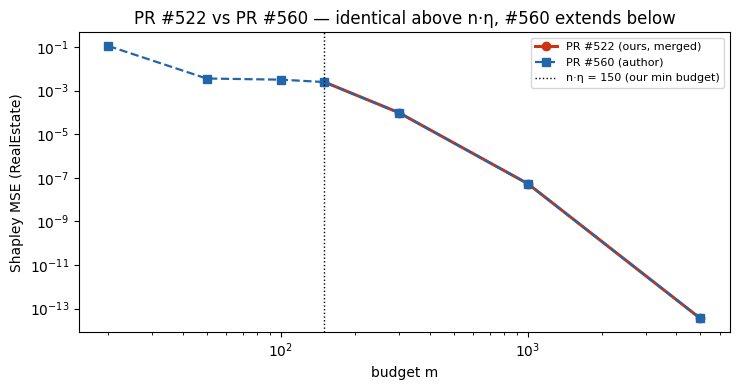

In [8]:
# Precomputed by `repro/experiment_variant_delta.py` (both vendored revisions through the
# identical value function / ground truth). Regenerate with:
#   uv run python -m repro.experiment_variant_delta --vf realestate
vd = read_csv("variant_delta_realestate.csv")
min_budget = int(float(vd[0]["min_budget_v522"]))
n_vd = int(float(vd[0]["n"]))
print(f"RealEstate d={n_vd};  PR #522 min budget = n·η = {min_budget};  PR #560 min budget = η = 10\n")
print(f"{'budget':>8} {'#522 (ours)':>14} {'#560 (author)':>14}  note")
rows = []
for r in vd:
    b = int(r["budget"])
    a = float(r["v522_mse"]) if r["v522_mse"] else None
    c = float(r["v560_mse"])
    note = "identical" if a and abs(a - c) <= 1e-9 * max(a, c) else ("#560-only regime" if a is None else "")
    rows.append((b, a, c))
    print(f"{b:>8} {'REFUSED' if a is None else f'{a:.3e}':>14} {c:>14.3e}  {note}")

fig, ax = plt.subplots(figsize=(7.5, 4))
bs = [r[0] for r in rows]
ax.plot([r[0] for r in rows if r[1] is not None], [r[1] for r in rows if r[1] is not None],
        "o-", color="#CC3311", lw=2.2, label="PR #522 (ours, merged)")
ax.plot(bs, [r[2] for r in rows], "s--", color="#2266AA", lw=1.6, label="PR #560 (author)")
ax.axvline(min_budget, color="k", ls=":", lw=1, label=f"n·η = {min_budget} (our min budget)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("budget m"); ax.set_ylabel("Shapley MSE (RealEstate)")
ax.set_title("PR #522 vs PR #560 — identical above n·η, #560 extends below")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 7 — Beyond the paper: the odd decomposition extends to the semivalue family

OddSHAP rests on `φ_Shapley(f) = φ_Shapley(f_odd)` — the Shapley value depends only on the
odd part of the game's Fourier spectrum. A natural question the paper does not touch: is
this special to the Shapley value, or a property of the whole **semivalue** family?

The Banzhaf value gives a clean answer: it equals a single first-order Fourier coefficient,
`φ_i^Banzhaf = -2·β_{i}`, which is odd by construction. Below we verify the identity to
machine precision on random games — evidence that OddSHAP's odd-Fourier machinery transfers
to Banzhaf, and (since every semivalue is a linear functional of marginal contributions) to
arbitrary semivalues. A candidate direction for follow-up with the authors.

In [9]:
from shapiq.game_theory.exact import ExactComputer
from shapiq_games.synthetic import SOUM


def walsh_first_order(game, n):
    masks = np.array([[(k >> i) & 1 for i in range(n)] for k in range(2 ** n)], dtype=bool)
    vals = game(masks).astype(float)
    signs = np.where(masks, -1.0, 1.0)
    return (vals[:, None] * signs).mean(axis=0)


print("φ_i^Banzhaf  vs  -2·β_{i}   (max abs deviation over random games)")
worst = 0.0
for nn in (6, 8, 10):
    g = SOUM(n=nn, n_basis_games=12, max_interaction_size=3, random_state=0)
    bv = ExactComputer(game=g, n_players=nn)(index="BV", order=1)
    banzhaf = np.array([float(bv.dict_values.get((i,), 0.0)) for i in range(nn)])
    pred = -2.0 * walsh_first_order(g, nn)
    dev = float(np.max(np.abs(banzhaf - pred)))
    worst = max(worst, dev)
    print(f"  n={nn:2d}:  max|φ^B − (−2β)| = {dev:.2e}")
print(f"\nworst deviation: {worst:.1e}  →  identity holds to machine precision.")

φ_i^Banzhaf  vs  -2·β_{i}   (max abs deviation over random games)
  n= 6:  max|φ^B − (−2β)| = 2.22e-16
  n= 8:  max|φ^B − (−2β)| = 6.66e-16
  n=10:  max|φ^B − (−2β)| = 1.17e-15

worst deviation: 1.2e-15  →  identity holds to machine precision.


## Conclusion

OddSHAP reproduces the paper's headline across the tabular and deep-learning value
functions: **rank-1** on all six tabular value functions and on ViT16, rank-2 on
DistilBERT (matching the paper's low-dimension statement), and the interaction-sparsity
U-shape of Figure 4. The IQR panels show our N=30 spread overlaps the paper's Table-3
intervals. The pluggable-variant comparison isolates PR #560's contribution to the
low-budget regime, leaving every paper-scale result unchanged. Finally, the odd
decomposition that OddSHAP exploits is shown to be a semivalue-family property (verified
for Banzhaf), a candidate direction for follow-up.